In [ ]:
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

iris = load_breast_cancer()
X = iris.data
y = iris.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        43
           1       0.93      0.96      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

[[38  5]
 [ 3 68]]


In [ ]:
k_values = range(3, 20)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

In [ ]:
accuracies

[0.9298245614035088,
 0.9385964912280702,
 0.956140350877193,
 0.9649122807017544,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.9736842105263158,
 0.9824561403508771,
 0.9824561403508771,
 0.9736842105263158,
 0.9736842105263158,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544]

In [ ]:
max_accuracy = max(accuracies)
max_k = k_values[accuracies.index(max_accuracy)]

In [ ]:
max_k

11

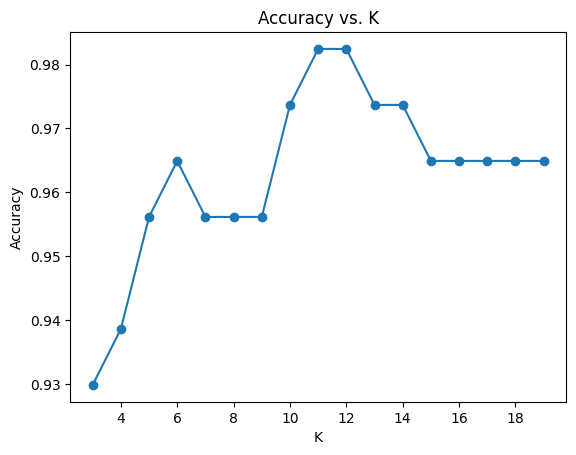

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('Accuracy vs. K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold


model = KNeighborsClassifier(n_neighbors=max_k)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kfold)

print('Scores: ', scores)
print('Avg Accuracy: ', scores.mean())

Scores:  [0.98245614 0.99122807 0.86842105 0.93859649 0.92035398]
Avg Accuracy:  0.9402111473373699


In [ ]:
model = KNeighborsClassifier(n_neighbors=max_k)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kfold)

print('Scores: ', scores)
print('Avg Accuracy: ', scores.mean())

Scores:  [0.93859649 0.9122807  0.92105263 0.96491228 0.9380531 ]
Avg Accuracy:  0.934979040521658


In [ ]:

k_values = range(3, 20)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, weights='uniform')

    scores = cross_val_score(model, X, y, cv=kfold)

    accuracies.append(scores.mean())

print(accuracies)

[np.float64(0.9279925477410339), np.float64(0.9139108834031984), np.float64(0.9350100916006833), np.float64(0.9314857941313461), np.float64(0.9279770222015215), np.float64(0.929731408166434), np.float64(0.9314702685918336), np.float64(0.934979040521658), np.float64(0.934979040521658), np.float64(0.9332401800962584), np.float64(0.9332246545567457), np.float64(0.9314702685918336), np.float64(0.9297158826269213), np.float64(0.9279614966620089), np.float64(0.9332246545567457), np.float64(0.9332246545567457), np.float64(0.9297158826269213)]


In [ ]:
max_accuracy = max(accuracies)
max_k = k_values[accuracies.index(max_accuracy)]

In [ ]:
max_k

5

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print("report:", report)

report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Text(50.722222222222214, 0.5, 'True')

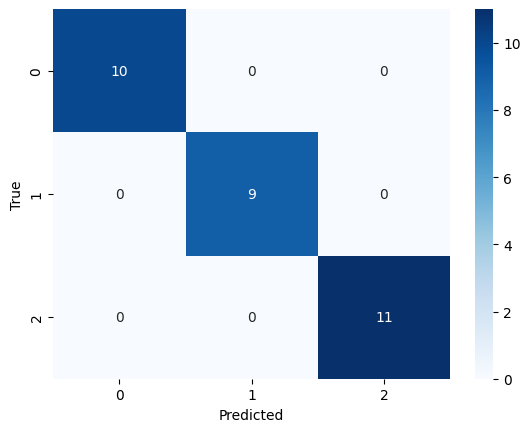

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')